In [1]:
pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 66.7 MB/s eta 0:00:00


In [3]:
import warnings
import logging

warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import logging
logging.getLogger().setLevel(logging.ERROR)


Cloning into 'Single-ion-phonon-laser-sensing'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 25 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 833.55 KiB | 10.83 MiB/s, done.
Resolving deltas: 100% (4/4), done.
replace ./B4_exp/B4_exp/Im chi/deltaphi 0.125pi/1/character.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
===== Extracted data directory content =====
B4_exp
Step 1: Running QuTiP theoretical simulation...

Step 2: Reading experimental raw scattered data...

Step 3: Performing 2D interpolation and data truncation...
Reconstructing Wigner function...

Step 5: Generating figure (1x4 panels)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: Fig1_Wigner_Reconstruction_2026-09-14.pdf


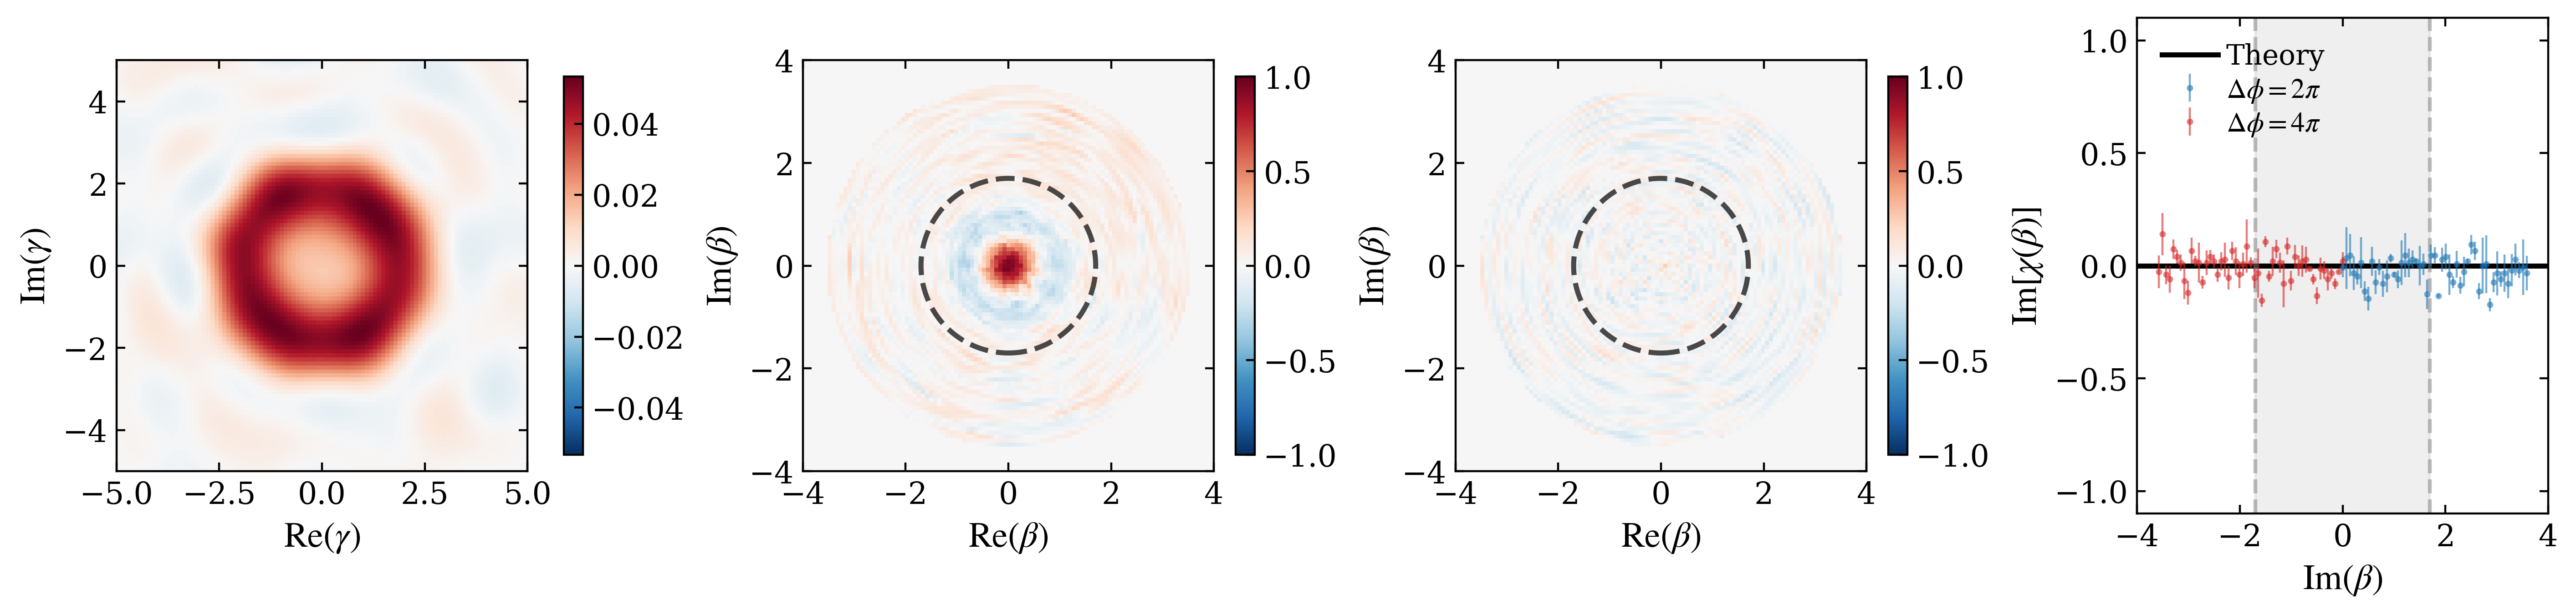


               Figure generated successfully.               
>> Large canvas (14x3.2) + 400DPI.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
from scipy.interpolate import griddata
from scipy.stats import sem
from matplotlib.colors import TwoSlopeNorm
from qutip import *
from google.colab import files
from datetime import datetime

# ================== Auto-download settings ==================
run_date = datetime.now().strftime("%Y-%m-%d")

def download_pdf(base_name):
    """Save the current figure as a PDF to the local machine."""
    filename = f"{base_name}_{run_date}.pdf"
    plt.gcf().savefig(filename, format='pdf', bbox_inches='tight', dpi=400)
    files.download(filename) # Auto-download in Colab
    print(f"Downloading: {filename}")

# ================== Auto-pull data from GitHub ==================
# 1. Clean up old cache
!rm -rf Single-ion-phonon-laser-sensing

# 2. Clone the repository
!git clone https://github.com/lipeidong1999/Single-ion-phonon-laser-sensing.git

# 3. Unzip experimental data
!unzip -q Single-ion-phonon-laser-sensing/experimental_data/Fig1_data/B4_exp.zip -d ./B4_exp/

# 4. [Key Check] Inspect the extracted data
print("===== Extracted data directory content =====")
!ls ./B4_exp/

# ================== Parameter settings ==================
eta = 0.114
Omega_eff_exp = 2 * np.pi * 50e3
t_theory_ms = 5.7
beta_cutoff = 1.7  # Physical reconstruction cutoff radius
N_grid = 101
xlim_alpha = 5
phi_d = 0

# 3. Modify base_path to point to the unzipped local path
# Note: The zip created an extra folder layer, so the path is "./B4_exp/B4_exp/"
base_path = "./B4_exp/B4_exp/"
path_Re = os.path.join(base_path, "Re chi")
path_Im = os.path.join(base_path, "Im chi")
dphi_list = np.arange(0.125*np.pi, 4*np.pi + 1e-12, 0.125*np.pi)

# ================== 1. Physical theory calculation (QuTiP) ==================
print("Step 1: Running QuTiP theoretical simulation...")
N_cutoff = 40
hbar, q_charge = 1.0545718e-34, 1.6021766e-19
m_ca40, omega_trap = 40 * 1.660539e-27, 2 * np.pi * 676.35e3
x0 = np.sqrt(hbar / (2 * m_ca40 * omega_trap))
drive_coeff = (0e-6 * q_charge * x0) / (2 * hbar)
Omegah = Omegac = 2 * np.pi * 40e3
gammah, gammac = 15e3, 150e3
delta = 0

a = tensor(destroy(N_cutoff), qeye(3))
g_s, eh, ec = basis(3, 0), basis(3, 1), basis(3, 2)
smh = tensor(qeye(N_cutoff), g_s * eh.dag())
smc = tensor(qeye(N_cutoff), g_s * ec.dag())
szh = tensor(qeye(N_cutoff), eh * eh.dag() - g_s * g_s.dag())
szc = tensor(qeye(N_cutoff), ec * ec.dag() - g_s * g_s.dag())

H = (-delta * a.dag() * a + 0.5 * delta * szh - 0.5 * delta * szc
     + 1j * drive_coeff * (a * np.exp(1j * phi_d) - a.dag() * np.exp(-1j * phi_d))
     + 0.5 * 1j * eta * Omegah * (a.dag() * smh.dag() - a * smh)
     + 0.5 * 1j * eta * Omegac * (a.dag() * smc - a * smc.dag()))
c_ops = [np.sqrt(gammah) * smh, np.sqrt(gammac) * smc]

res = mesolve(H, tensor(basis(N_cutoff, 0), g_s), [0, t_theory_ms*1e-3], c_ops, options={'nsteps': 10000})
rho_p = ptrace(res.states[-1], 0)

# Generate theoretical Wigner function
xvec_t = np.linspace(-xlim_alpha, xlim_alpha, N_grid)
W_theory = wigner(rho_p, xvec_t, xvec_t, g=2)

# Generate theoretical characteristic function
def calc_theory_chi(W, x_vec):
    dx = x_vec[1] - x_vec[0]
    mm, nn = np.meshgrid(x_vec, x_vec); gamma = mm + 1j * nn
    b_limit = 4.0
    b_v = np.linspace(-b_limit, b_limit, N_grid)
    br, bi = np.meshgrid(b_v, b_v)
    chi = np.zeros((N_grid, N_grid), dtype=np.complex128)
    for i in range(N_grid):
        for j in range(N_grid):
            b = br[i, j] + 1j * bi[i, j]
            chi[i, j] = np.sum(W * np.exp(b * np.conj(gamma) - np.conj(b) * gamma)) * dx**2
    return b_v, chi

theory_b_vec, chi_theory_mat = calc_theory_chi(W_theory, xvec_t)

# ================== 2. Read experimental data ==================
print("\nStep 2: Reading experimental raw scattered data...")
exp_bx, exp_by, exp_chi_re, exp_chi_im = [], [], [], []

for dphi in dphi_list:
    folder_name = f"deltaphi {dphi/np.pi:.3f}pi"
    f_re = os.path.join(path_Re, folder_name, "character.txt")
    f_im = os.path.join(path_Im, folder_name, "character.txt")
    if os.path.exists(f_re) and os.path.exists(f_im):
        t_re, p_re = np.loadtxt(f_re).T
        t_im, p_im = np.loadtxt(f_im).T
        for i in range(min(len(t_re), len(t_im))):
            b = -1j * eta * Omega_eff_exp * (t_re[i] * 1e-3) * np.exp(-1j * dphi/2)
            exp_bx.append(b.real); exp_by.append(b.imag)
            exp_chi_re.append(1 - 2*p_re[i]); exp_chi_im.append(1 - 2*p_im[i])

exp_bx, exp_by = np.array(exp_bx), np.array(exp_by)
exp_chi_re, exp_chi_im = np.array(exp_chi_re), np.array(exp_chi_im)

# ================== 3. 2D Interpolation and truncation ==================
print("\nStep 3: Performing 2D interpolation and data truncation...")
max_b = theory_b_vec[-1]
BX, BY = np.meshgrid(theory_b_vec, theory_b_vec)

X1_re = griddata((exp_bx, exp_by), exp_chi_re, (BX, BY), method='cubic', fill_value=0.0)
X1_im = griddata((exp_bx, exp_by), exp_chi_im, (BX, BY), method='cubic', fill_value=0.0)

X1_recon_re = X1_re.copy()
X1_recon_im = X1_im.copy()
mask = np.sqrt(BX**2 + BY**2) > beta_cutoff
X1_recon_re[mask], X1_recon_im[mask] = 0.0, 0.0

# ================== 4. Wigner Reconstruction ==================
def compute_wigner_stable(X_comp, b_v, a_l, N):
    av = np.linspace(-a_l, a_l, N)
    AX, AY = np.meshgrid(av, av); alph = AX + 1j * AY
    br, bi = np.meshgrid(b_v, b_v); bg = br + 1j * bi
    W = np.zeros((N, N))
    area = (b_v[1] - b_v[0])**2
    print("Reconstructing Wigner function...")
    for i in range(N):
        for j in range(N):
            a = alph[i, j]
            kernel = np.exp(a * np.conj(bg) - np.conj(a) * bg)
            W[i, j] = (1.0/np.pi**2) * np.sum(X_comp * kernel).real * area
    return W

W_recon = compute_wigner_stable(X1_recon_re + 1j*X1_recon_im, theory_b_vec, xlim_alpha, N_grid)

# ================== 5. Generate Fig. 1 (1x4 figure panels) ==================
print("\nStep 5: Generating figure (1x4 panels)...")

mpl.rcParams['text.usetex'] = False
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'serif']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True

mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 11

fig, axes = plt.subplots(1, 4, figsize=(14.0, 3.2), dpi=400, constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.03, h_pad=0.01, hspace=0, wspace=0.03)

norm_chi = mpl.colors.Normalize(vmin=-1, vmax=1)

# --- Panel 1: Reconstructed Wigner function ---
w_max_r = max(abs(W_recon.min()), abs(W_recon.max()))
norm_r = TwoSlopeNorm(vmin=-w_max_r if w_max_r > 1e-10 else -1, vcenter=0, vmax=w_max_r if w_max_r > 1e-10 else 1)
im0 = axes[0].imshow(W_recon, extent=[-xlim_alpha, xlim_alpha, -xlim_alpha, xlim_alpha], origin='lower', cmap='RdBu_r', norm=norm_r)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.03)
axes[0].set_xlabel(r'$\mathrm{Re}(\gamma)$')
axes[0].set_ylabel(r'$\mathrm{Im}(\gamma)$')

# --- Panel 2: Re(chi) ---
im1 = axes[1].imshow(X1_re, extent=[-max_b, max_b, -max_b, max_b], origin='lower', cmap='RdBu_r', norm=norm_chi)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.03)
circle1 = plt.Circle((0, 0), beta_cutoff, color='black', fill=False, ls='--', lw=2.0, alpha=0.7)
axes[1].add_patch(circle1)
axes[1].set_xlabel(r'$\mathrm{Re}(\beta)$')
axes[1].set_ylabel(r'$\mathrm{Im}(\beta)$')

# --- Panel 3: Im(chi) ---
im2 = axes[2].imshow(X1_im, extent=[-max_b, max_b, -max_b, max_b], origin='lower', cmap='RdBu_r', norm=norm_chi)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.03)
circle2 = plt.Circle((0, 0), beta_cutoff, color='black', fill=False, ls='--', lw=2.0, alpha=0.7)
axes[2].add_patch(circle2)
axes[2].set_xlabel(r'$\mathrm{Re}(\beta)$')
axes[2].set_ylabel(r'$\mathrm{Im}(\beta)$')

# --- Panel 4: Linecut ---
axes[3].plot(theory_b_vec, np.imag(chi_theory_mat)[:, N_grid//2], 'k-', lw=2.0, label='Theory', zorder=1)

target_phis = {2.0: {'color': '#1f77b4', 'label': r'$\Delta\phi=2\pi$'},
               1.0: {'color': '#d62728', 'label': r'$\Delta\phi=4\pi$'}}

for phi_val, info in target_phis.items():
    folder_name = f"deltaphi {phi_val:.3f}pi"
    sub_vals = []
    for sub in ['1', '2', '3']:
        f_p = os.path.join(path_Im, folder_name, sub, "character.txt")
        if os.path.exists(f_p):
            t_s, p_s = np.loadtxt(f_p).T
            sub_vals.append(1 - 2*p_s)
    if sub_vals:
        avg_v, sem_v = np.mean(sub_vals, axis=0), sem(sub_vals, axis=0)
        direction = 1 if phi_val == 2.0 else -1
        b_imag_vals = direction * (eta * Omega_eff_exp * (t_s * 1e-3))

        axes[3].errorbar(b_imag_vals, avg_v, yerr=sem_v, fmt='o', color=info['color'],
                         ms=2.5, alpha=0.6, capsize=0, elinewidth=0.8,
                         markeredgewidth=0, errorevery=1, label=info['label'], zorder=3)

axes[3].axvspan(-beta_cutoff, beta_cutoff, color='gray', alpha=0.12, zorder=0)
axes[3].axvline(beta_cutoff, color='gray', lw=1.5, ls='--', alpha=0.5)
axes[3].axvline(-beta_cutoff, color='gray', lw=1.5, ls='--', alpha=0.5)

axes[3].set_ylim(-1.1, 1.1)
axes[3].set_xlim(-max_b, max_b)
axes[3].set_xlabel(r'$\mathrm{Im}(\beta)$')
axes[3].set_ylabel(r'$\mathrm{Im}[\chi(\beta)]$')
axes[3].legend(loc='upper left', frameon=False, handletextpad=0.3, labelspacing=0.2)

download_pdf("Fig1_Wigner_Reconstruction")
plt.show()

# ================== 6. Output parameters ==================
t_cutoff_us = (beta_cutoff / (eta * Omega_eff_exp)) * 1e6
t_max_display_us = (max_b / (eta * Omega_eff_exp)) * 1e6

print("\n" + "="*70)
print("Figure generated successfully.".center(60))
print(">> Large canvas (14x3.2) + 400DPI.")
print("="*70)

Cloning into 'Single-ion-phonon-laser-sensing'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 25 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 833.55 KiB | 9.69 MiB/s, done.
Resolving deltas: 100% (4/4), done.
===== Extracted data directory content =====
B4_100uV0phi_exp
Step 1: Running QuTiP theoretical simulation...

Step 2: Reading experimental raw scattered data...

Step 3: Performing 2D interpolation and data truncation...
Reconstructing Wigner function...

Step 5: Generating figure (1x4 panels)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: Fig1_Wigner_Reconstruction_100uV_2026-09-14.pdf


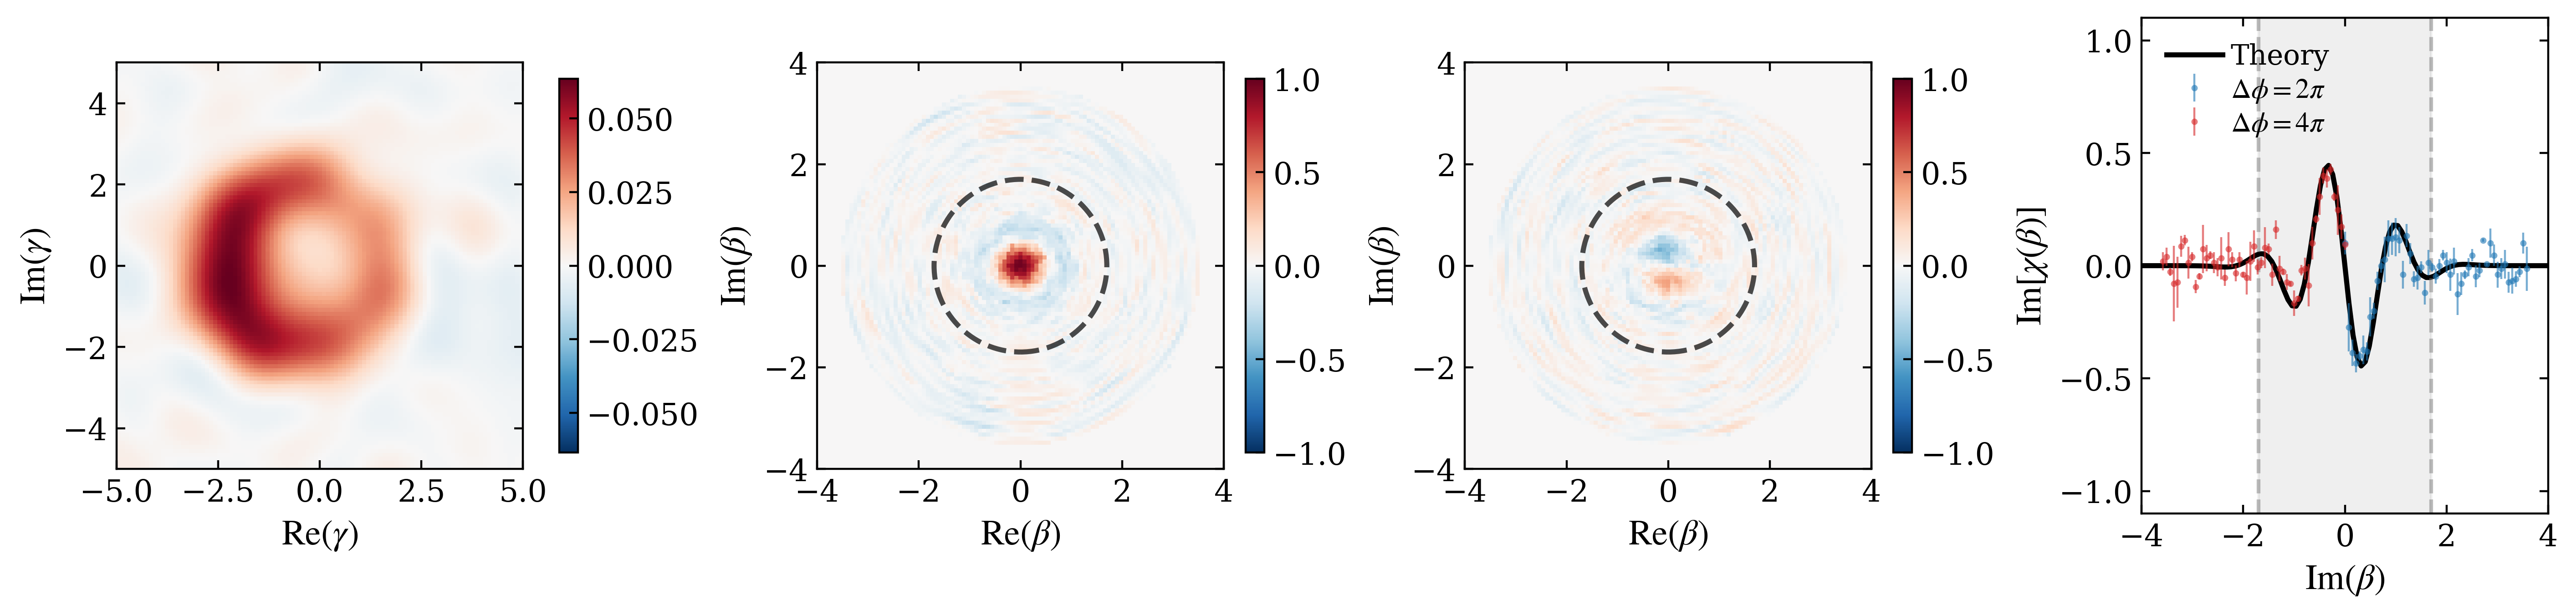


               Figure generated successfully.               
>> Large canvas (14x3.2) + 400DPI.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
from scipy.interpolate import griddata
from scipy.stats import sem
from matplotlib.colors import TwoSlopeNorm
from qutip import *
from google.colab import files
from datetime import datetime

# ================== Auto-download settings ==================
run_date = datetime.now().strftime("%Y-%m-%d")

def download_pdf(base_name):
    """Save the current figure as a PDF to the local machine."""
    filename = f"{base_name}_{run_date}.pdf"
    plt.gcf().savefig(filename, format='pdf', bbox_inches='tight', dpi=400)
    files.download(filename) # Auto-download in Colab
    print(f"Downloading: {filename}")

# ================== Auto-pull data from GitHub ==================
# 1. Clean up old cache
!rm -rf Single-ion-phonon-laser-sensing

# 2. Clone the repository
!git clone https://github.com/lipeidong1999/Single-ion-phonon-laser-sensing.git

# 3. Unzip experimental data (100uV drive data)
!unzip -q Single-ion-phonon-laser-sensing/experimental_data/Fig1_data/B4_100uV0phi_exp.zip -d ./B4_100uV0phi_exp/

# 4. [Key Check] Inspect the extracted data
print("===== Extracted data directory content =====")
!ls ./B4_100uV0phi_exp/

# ================== Parameter settings ==================
eta = 0.114
Omega_eff_exp = 2 * np.pi * 50e3
t_theory_ms = 5.7
beta_cutoff = 1.7  # Physical reconstruction cutoff radius
N_grid = 101
xlim_alpha = 5
phi_d = 0

# 3. Modify base_path to point to the unzipped local path
# Note: If the zip file creates an extra folder layer, the path should be "./B4_100uV0phi_exp/B4_100uV0phi_exp/"
# You can check the output of the '!ls' command above. Usually, it's an extra layer.
base_path = "./B4_100uV0phi_exp/B4_100uV0phi_exp/"
path_Re = os.path.join(base_path, "Re chi")
path_Im = os.path.join(base_path, "Im chi")
dphi_list = np.arange(0.125*np.pi, 4*np.pi + 1e-12, 0.125*np.pi)

# ================== 1. Physical theory calculation (QuTiP) ==================
print("Step 1: Running QuTiP theoretical simulation...")
N_cutoff = 40
hbar, q_charge = 1.0545718e-34, 1.6021766e-19
m_ca40, omega_trap = 40 * 1.660539e-27, 2 * np.pi * 676.35e3
x0 = np.sqrt(hbar / (2 * m_ca40 * omega_trap))
drive_coeff = (100e-6 * q_charge * x0) / (2 * hbar) # 100uV/m drive
Omegah = Omegac = 2 * np.pi * 40e3
gammah, gammac = 15e3, 150e3
delta = 0

a = tensor(destroy(N_cutoff), qeye(3))
g_s, eh, ec = basis(3, 0), basis(3, 1), basis(3, 2)
smh = tensor(qeye(N_cutoff), g_s * eh.dag())
smc = tensor(qeye(N_cutoff), g_s * ec.dag())
szh = tensor(qeye(N_cutoff), eh * eh.dag() - g_s * g_s.dag())
szc = tensor(qeye(N_cutoff), ec * ec.dag() - g_s * g_s.dag())

H = (-delta * a.dag() * a + 0.5 * delta * szh - 0.5 * delta * szc
     + 1j * drive_coeff * (a * np.exp(1j * phi_d) - a.dag() * np.exp(-1j * phi_d))
     + 0.5 * 1j * eta * Omegah * (a.dag() * smh.dag() - a * smh)
     + 0.5 * 1j * eta * Omegac * (a.dag() * smc - a * smc.dag()))
c_ops = [np.sqrt(gammah) * smh, np.sqrt(gammac) * smc]

res = mesolve(H, tensor(basis(N_cutoff, 0), g_s), [0, t_theory_ms*1e-3], c_ops, options={'nsteps': 10000})
rho_p = ptrace(res.states[-1], 0)

# Generate theoretical Wigner function
xvec_t = np.linspace(-xlim_alpha, xlim_alpha, N_grid)
W_theory = wigner(rho_p, xvec_t, xvec_t, g=2)

# Generate theoretical characteristic function
def calc_theory_chi(W, x_vec):
    dx = x_vec[1] - x_vec[0]
    mm, nn = np.meshgrid(x_vec, x_vec); gamma = mm + 1j * nn
    b_limit = 4.0
    b_v = np.linspace(-b_limit, b_limit, N_grid)
    br, bi = np.meshgrid(b_v, b_v)
    chi = np.zeros((N_grid, N_grid), dtype=np.complex128)
    for i in range(N_grid):
        for j in range(N_grid):
            b = br[i, j] + 1j * bi[i, j]
            chi[i, j] = np.sum(W * np.exp(b * np.conj(gamma) - np.conj(b) * gamma)) * dx**2
    return b_v, chi

theory_b_vec, chi_theory_mat = calc_theory_chi(W_theory, xvec_t)

# ================== 2. Read experimental data ==================
print("\nStep 2: Reading experimental raw scattered data...")
exp_bx, exp_by, exp_chi_re, exp_chi_im = [], [], [], []

for dphi in dphi_list:
    folder_name = f"deltaphi {dphi/np.pi:.3f}pi"
    f_re = os.path.join(path_Re, folder_name, "character.txt")
    f_im = os.path.join(path_Im, folder_name, "character.txt")
    if os.path.exists(f_re) and os.path.exists(f_im):
        t_re, p_re = np.loadtxt(f_re).T
        t_im, p_im = np.loadtxt(f_im).T
        for i in range(min(len(t_re), len(t_im))):
            b = -1j * eta * Omega_eff_exp * (t_re[i] * 1e-3) * np.exp(-1j * dphi/2)
            exp_bx.append(b.real); exp_by.append(b.imag)
            exp_chi_re.append(1 - 2*p_re[i]); exp_chi_im.append(1 - 2*p_im[i])

exp_bx, exp_by = np.array(exp_bx), np.array(exp_by)
exp_chi_re, exp_chi_im = np.array(exp_chi_re), np.array(exp_chi_im)

# ================== 3. 2D Interpolation and truncation ==================
print("\nStep 3: Performing 2D interpolation and data truncation...")
max_b = theory_b_vec[-1]
BX, BY = np.meshgrid(theory_b_vec, theory_b_vec)

X1_re = griddata((exp_bx, exp_by), exp_chi_re, (BX, BY), method='cubic', fill_value=0.0)
X1_im = griddata((exp_bx, exp_by), exp_chi_im, (BX, BY), method='cubic', fill_value=0.0)

X1_recon_re = X1_re.copy()
X1_recon_im = X1_im.copy()
mask = np.sqrt(BX**2 + BY**2) > beta_cutoff
X1_recon_re[mask], X1_recon_im[mask] = 0.0, 0.0

# ================== 4. Wigner Reconstruction ==================
def compute_wigner_stable(X_comp, b_v, a_l, N):
    av = np.linspace(-a_l, a_l, N)
    AX, AY = np.meshgrid(av, av); alph = AX + 1j * AY
    br, bi = np.meshgrid(b_v, b_v); bg = br + 1j * bi
    W = np.zeros((N, N))
    area = (b_v[1] - b_v[0])**2
    print("Reconstructing Wigner function...")
    for i in range(N):
        for j in range(N):
            a = alph[i, j]
            kernel = np.exp(a * np.conj(bg) - np.conj(a) * bg)
            W[i, j] = (1.0/np.pi**2) * np.sum(X_comp * kernel).real * area
    return W

W_recon = compute_wigner_stable(X1_recon_re + 1j*X1_recon_im, theory_b_vec, xlim_alpha, N_grid)

# ================== 5. Generate Fig. 1 (1x4 figure panels) ==================
print("\nStep 5: Generating figure (1x4 panels)...")

mpl.rcParams['text.usetex'] = False
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'serif']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True

mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 11

fig, axes = plt.subplots(1, 4, figsize=(14.0, 3.2), dpi=400, constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.03, h_pad=0.01, hspace=0, wspace=0.03)

norm_chi = mpl.colors.Normalize(vmin=-1, vmax=1)

# --- Panel 1: Reconstructed Wigner function ---
w_max_r = max(abs(W_recon.min()), abs(W_recon.max()))
norm_r = TwoSlopeNorm(vmin=-w_max_r if w_max_r > 1e-10 else -1, vcenter=0, vmax=w_max_r if w_max_r > 1e-10 else 1)
im0 = axes[0].imshow(W_recon, extent=[-xlim_alpha, xlim_alpha, -xlim_alpha, xlim_alpha], origin='lower', cmap='RdBu_r', norm=norm_r)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.03)
axes[0].set_xlabel(r'$\mathrm{Re}(\gamma)$')
axes[0].set_ylabel(r'$\mathrm{Im}(\gamma)$')

# --- Panel 2: Re(chi) ---
im1 = axes[1].imshow(X1_re, extent=[-max_b, max_b, -max_b, max_b], origin='lower', cmap='RdBu_r', norm=norm_chi)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.03)
circle1 = plt.Circle((0, 0), beta_cutoff, color='black', fill=False, ls='--', lw=2.0, alpha=0.7)
axes[1].add_patch(circle1)
axes[1].set_xlabel(r'$\mathrm{Re}(\beta)$')
axes[1].set_ylabel(r'$\mathrm{Im}(\beta)$')

# --- Panel 3: Im(chi) ---
im2 = axes[2].imshow(X1_im, extent=[-max_b, max_b, -max_b, max_b], origin='lower', cmap='RdBu_r', norm=norm_chi)
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.03)
circle2 = plt.Circle((0, 0), beta_cutoff, color='black', fill=False, ls='--', lw=2.0, alpha=0.7)
axes[2].add_patch(circle2)
axes[2].set_xlabel(r'$\mathrm{Re}(\beta)$')
axes[2].set_ylabel(r'$\mathrm{Im}(\beta)$')

# --- Panel 4: Linecut ---
axes[3].plot(theory_b_vec, np.imag(chi_theory_mat)[:, N_grid//2], 'k-', lw=2.0, label='Theory', zorder=1)

target_phis = {2.0: {'color': '#1f77b4', 'label': r'$\Delta\phi=2\pi$'},
               4.0: {'color': '#d62728', 'label': r'$\Delta\phi=4\pi$'}}

for phi_val, info in target_phis.items():
    folder_name = f"deltaphi {phi_val:.3f}pi"
    sub_vals = []
    for sub in ['1', '2', '3']:
        f_p = os.path.join(path_Im, folder_name, sub, "character.txt")
        if os.path.exists(f_p):
            t_s, p_s = np.loadtxt(f_p).T
            sub_vals.append(1 - 2*p_s)
    if sub_vals:
        avg_v, sem_v = np.mean(sub_vals, axis=0), sem(sub_vals, axis=0)
        direction = 1 if phi_val == 2.0 else -1
        b_imag_vals = direction * (eta * Omega_eff_exp * (t_s * 1e-3))

        axes[3].errorbar(b_imag_vals, avg_v, yerr=sem_v, fmt='o', color=info['color'],
                         ms=2.5, alpha=0.6, capsize=0, elinewidth=0.8,
                         markeredgewidth=0, errorevery=1, label=info['label'], zorder=3)

axes[3].axvspan(-beta_cutoff, beta_cutoff, color='gray', alpha=0.12, zorder=0)
axes[3].axvline(beta_cutoff, color='gray', lw=1.5, ls='--', alpha=0.5)
axes[3].axvline(-beta_cutoff, color='gray', lw=1.5, ls='--', alpha=0.5)

axes[3].set_ylim(-1.1, 1.1)
axes[3].set_xlim(-max_b, max_b)
axes[3].set_xlabel(r'$\mathrm{Im}(\beta)$')
axes[3].set_ylabel(r'$\mathrm{Im}[\chi(\beta)]$')
axes[3].legend(loc='upper left', frameon=False, handletextpad=0.3, labelspacing=0.2)

download_pdf("Fig1_Wigner_Reconstruction_100uV")
plt.show()

# ================== 6. Output parameters ==================
t_cutoff_us = (beta_cutoff / (eta * Omega_eff_exp)) * 1e6
t_max_display_us = (max_b / (eta * Omega_eff_exp)) * 1e6

print("\n" + "="*70)
print("Figure generated successfully.".center(60))
print(">> Large canvas (14x3.2) + 400DPI.")
print("="*70)